## What is Employee Attrition?

Employee Attrition refers to the gradual reduction of a company's workforce due to employees leaving — whether through resignation, retirement, or other voluntary/involuntary departures — without immediate replacement. It is one of the most critical HR metrics that directly impacts organizational performance, culture, and costs.

---

### Why is Attrition Prediction Important?

Understanding and predicting employee attrition is vital for organizations for several reasons:

| Reason | Impact |
|---|---|
| **Cost Reduction** | Replacing an employee costs 50–200% of their annual salary (recruiting, onboarding, training) |
| **Knowledge Retention** | Experienced employees carry institutional knowledge; attrition causes knowledge drain |
| **Productivity Impact** | High attrition disrupts team cohesion and reduces overall productivity |
| **Talent Strategy** | Enables HR to proactively intervene and improve retention strategies |
| **Workforce Planning** | Helps predict future hiring needs and succession planning |

---

### Objective of This Analysis

The goal of this **Exploratory Data Analysis (EDA)** is to:

1. **Understand the dataset** — structure, data types, missing values, and distributions
2. **Identify patterns** — which employee groups are most prone to leaving
3. **Uncover correlations** — which features are most strongly associated with attrition
4. **Generate business insights** — actionable findings that can guide HR decision-making

---

##  Import Required Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"]  = (10, 5)
plt.rcParams["axes.titlesize"]  = 14
plt.rcParams["axes.labelsize"]  = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print('All libraries imported successfully.')

All libraries imported successfully.


## Load Dataset


We load the IBM HR Employee Attrition dataset using `pandas`. The dataset contains various employee attributes alongside a binary `Attrition` label indicating whether an employee left the company.

In [21]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv("../data/HR-Employee-Attrition-Data.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1470 rows × 35 columns


###  First 5 Rows

In [22]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


###  Last 5 Rows

In [23]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


###  Dataset Dimensions

In [8]:
print(f" Number of Rows    : {df.shape[0]}")
print(f" Number of Columns : {df.shape[1]}")
print(f" Total Data Points : {df.shape[0] * df.shape[1]:,}")

 Number of Rows    : 1470
 Number of Columns : 35
 Total Data Points : 51,450


## Dataset Overview

We examine the structure of the dataset — including column names, data types, non-null counts, and basic statistical summaries.

In [24]:
# ── Dataset Info ─────────────────────────────────────────────────────────────
print("=" * 55)
print("         DATASET STRUCTURE OVERVIEW")
print("=" * 55)
df.info()

         DATASET STRUCTURE OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   

### Statistical Summary — Numerical Features

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### Data Type Breakdown

| Category | Count |
|---|---|
| Numerical (int64 / float64) | See below |
| Categorical (object) | See below |

In [26]:
num_cols  = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols  = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features  : {len(num_cols)}")
print(f"Categorical Features: {len(cat_cols)}")

 Numerical Features  : 26
Categorical Features: 9


## Check Missing Values

Before any analysis, we must verify data completeness. Missing values can distort statistics and lead to misleading insights.

In [27]:
# ── Missing Values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %"    : missing_pct.round(2)
}).sort_values("Missing Count", ascending=False)

print(missing_df[missing_df["Missing Count"] > 0] if missing_df["Missing Count"].sum() > 0
      else " No missing values found in the dataset!")

 No missing values found in the dataset!


###  Insight — Missing Values

> **The IBM HR Attrition dataset is clean and complete.** There are **no missing values** across all 35 columns. This means we can proceed directly to analysis without any imputation or data filling steps.
> This is expected for this well-curated IBM benchmark dataset.

## Check Duplicate Records

In [28]:
# ── Duplicate Check ──────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f" Total Duplicate Rows: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate records found. Dataset is clean!")

 Total Duplicate Rows: 0
No duplicate records found. Dataset is clean!


## Identify Feature Types

We separate all columns into **numerical** and **categorical** groups for targeted analysis.

In [29]:
# ── Feature Separation ───────────────────────────────────────────────────────
numerical_features   = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("NUMERICAL FEATURES:")
print("-" * 45)
for i, col in enumerate(numerical_features, 1):
    print(f"  {i:02d}. {col}")

print(f"\nCATEGORICAL FEATURES:")
print("-" * 45)
for i, col in enumerate(categorical_features, 1):
    print(f"  {i:02d}. {col}")

print(f"\n Total Numerical  : {len(numerical_features)}")
print(f" Total Categorical : {len(categorical_features)}")

NUMERICAL FEATURES:
---------------------------------------------
  01. Age
  02. DailyRate
  03. DistanceFromHome
  04. Education
  05. EmployeeCount
  06. EmployeeNumber
  07. EnvironmentSatisfaction
  08. HourlyRate
  09. JobInvolvement
  10. JobLevel
  11. JobSatisfaction
  12. MonthlyIncome
  13. MonthlyRate
  14. NumCompaniesWorked
  15. PercentSalaryHike
  16. PerformanceRating
  17. RelationshipSatisfaction
  18. StandardHours
  19. StockOptionLevel
  20. TotalWorkingYears
  21. TrainingTimesLastYear
  22. WorkLifeBalance
  23. YearsAtCompany
  24. YearsInCurrentRole
  25. YearsSinceLastPromotion
  26. YearsWithCurrManager

CATEGORICAL FEATURES:
---------------------------------------------
  01. Attrition
  02. BusinessTravel
  03. Department
  04. EducationField
  05. Gender
  06. JobRole
  07. MaritalStatus
  08. Over18
  09. OverTime

 Total Numerical  : 26
 Total Categorical : 9


## Target Variable Analysis — `Attrition`

The target variable `Attrition` is a binary categorical variable:
- **"Yes"** — Employee left the company
- **"No"** — Employee is still with the company

Understanding the distribution of the target variable helps us detect class imbalance, which is crucial for any downstream modeling.

Attrition Distribution:
-----------------------------------
  No    → 1233 employees (83.9%)
  Yes   →  237 employees (16.1%)


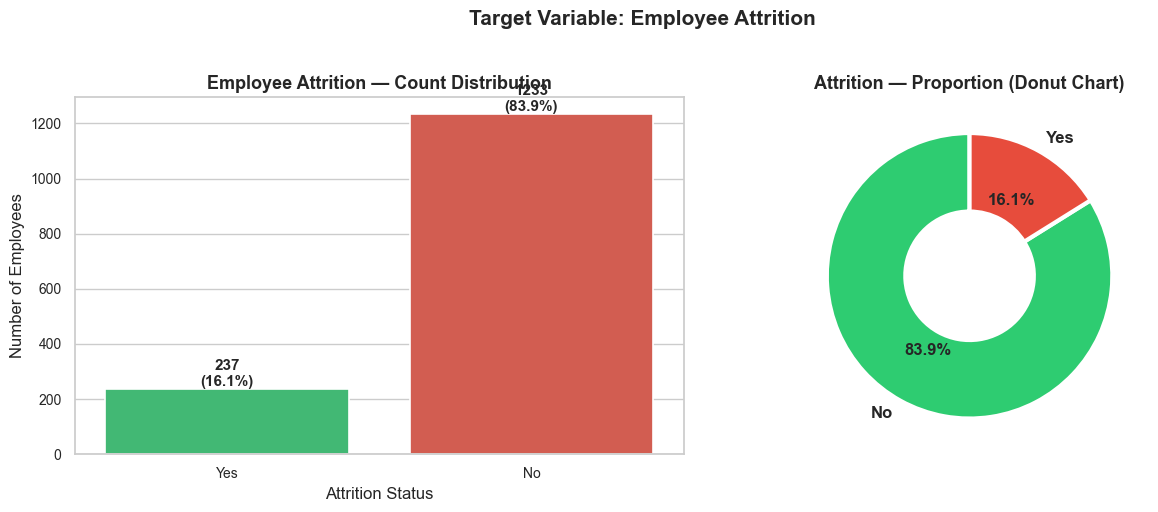

In [30]:
# ── Target Variable Distribution ─────────────────────────────────────────────
attrition_counts = df["Attrition"].value_counts()
attrition_pct    = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition Distribution:")
print("-" * 35)
for label in attrition_counts.index:
    print(f"  {label:5s} → {attrition_counts[label]:4d} employees ({attrition_pct[label]:.1f}%)")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count Plot
colors = ["#2ecc71", "#e74c3c"]
sns.countplot(data=df, x="Attrition", palette=colors, ax=axes[0], edgecolor="white", linewidth=1.2)
axes[0].set_title("Employee Attrition — Count Distribution", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Attrition Status")
axes[0].set_ylabel("Number of Employees")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")

# Pie Chart
wedge_props = dict(width=0.55, edgecolor="white", linewidth=3)
axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops=wedge_props,
            textprops={"fontsize": 12, "fontweight": "bold"})
axes[1].set_title("Attrition — Proportion (Donut Chart)", fontweight="bold", fontsize=13)

plt.suptitle("Target Variable: Employee Attrition", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Insight — Target Variable

> - The dataset is **imbalanced**: approximately **84% of employees stayed** (`No`) vs **16% who left** (`Yes`).
> - This confirms a classic **class imbalance** scenario — a common challenge in attrition prediction tasks.
> - Out of 1,470 employees, **237 left** the organization, which represents a meaningful but minority class.
> - In future modeling phases, techniques like **SMOTE**, **class weighting**, or **stratified sampling** should be used to handle this imbalance.

---

## Univariate Analysis

We examine the distribution of key individual features to understand their spread, skewness, and frequency. This helps us understand **who** the employees are in this dataset.

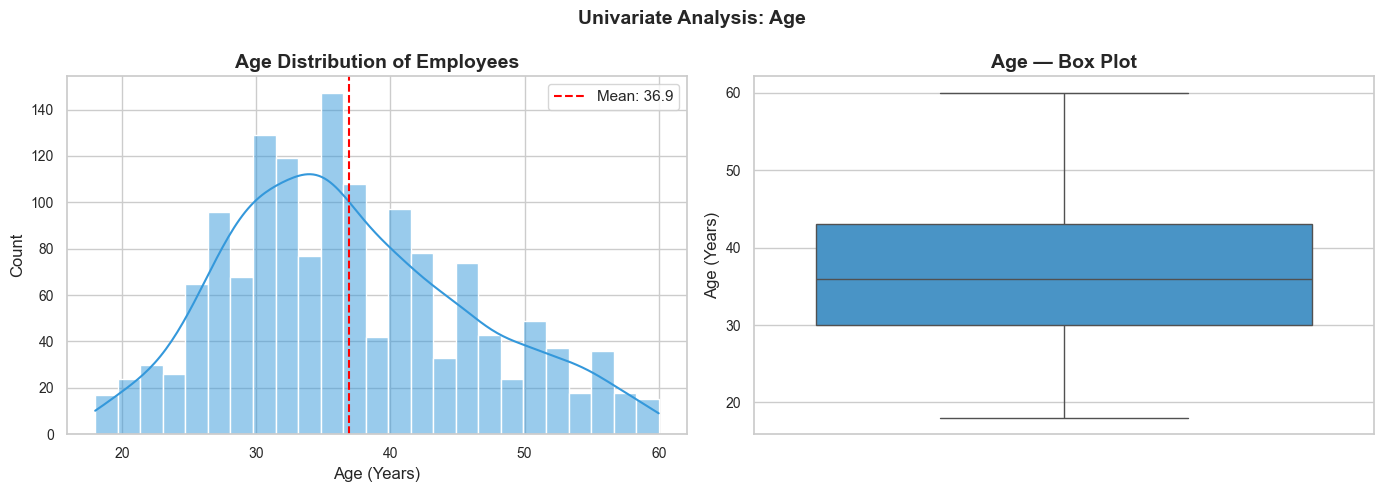

   Age Statistics:
   Mean   : 36.9 years
   Median : 36.0 years
   Std Dev: 9.1 years
   Range  : 18 – 60 years


In [31]:
# ── Age Distribution ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Age"], bins=25, kde=True, color="#3498db", edgecolor="white", ax=axes[0])
axes[0].set_title("Age Distribution of Employees", fontweight="bold")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["Age"].mean(), color="red", linestyle="--", label=f"Mean: {df['Age'].mean():.1f}")
axes[0].legend()

sns.boxplot(y=df["Age"], color="#3498db", ax=axes[1])
axes[1].set_title("Age — Box Plot", fontweight="bold")
axes[1].set_ylabel("Age (Years)")

plt.suptitle("Univariate Analysis: Age", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"   Age Statistics:")
print(f"   Mean   : {df['Age'].mean():.1f} years")
print(f"   Median : {df['Age'].median():.1f} years")
print(f"   Std Dev: {df['Age'].std():.1f} years")
print(f"   Range  : {df['Age'].min()} – {df['Age'].max()} years")

### 💡 Insight — Age
> - The age distribution is **approximately normal**, centered around **36–37 years**.
> - The majority of employees fall in the **25–45 age range**, reflecting a mid-career workforce.
> - Younger employees (20–30) are more likely to leave as they explore career options early.

---

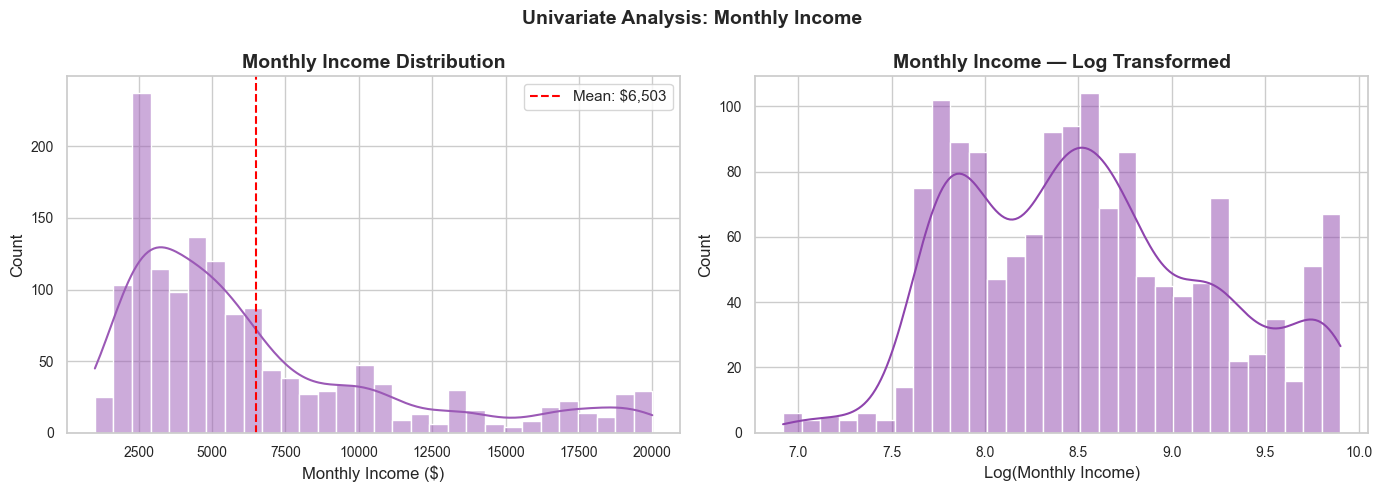

 Monthly Income Statistics:
   Mean   : $6,503
   Median : $4,919
   Min    : $1,009
   Max    : $19,999


In [33]:
# ── Monthly Income Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["MonthlyIncome"], bins=30, kde=True, color="#9b59b6", edgecolor="white", ax=axes[0])
axes[0].set_title("Monthly Income Distribution", fontweight="bold")
axes[0].set_xlabel("Monthly Income ($)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["MonthlyIncome"].mean(), color="red", linestyle="--",
                label=f"Mean: ${df['MonthlyIncome'].mean():,.0f}")
axes[0].legend()

sns.histplot(np.log1p(df["MonthlyIncome"]), bins=30, kde=True, color="#8e44ad", edgecolor="white", ax=axes[1])
axes[1].set_title("Monthly Income — Log Transformed", fontweight="bold")
axes[1].set_xlabel("Log(Monthly Income)")
axes[1].set_ylabel("Count")

plt.suptitle("Univariate Analysis: Monthly Income", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f" Monthly Income Statistics:")
print(f"   Mean   : ${df['MonthlyIncome'].mean():,.0f}")
print(f"   Median : ${df['MonthlyIncome'].median():,.0f}")
print(f"   Min    : ${df['MonthlyIncome'].min():,}")
print(f"   Max    : ${df['MonthlyIncome'].max():,}")

### Insight — Monthly Income
> - Monthly income is **right-skewed**, with most employees earning in the lower range and a long tail of higher earners.
> - The mean ($6,503) is higher than the median (~$4,919), confirming the right skew.
> - Lower-income employees are significantly more likely to leave due to financial motivations.

---

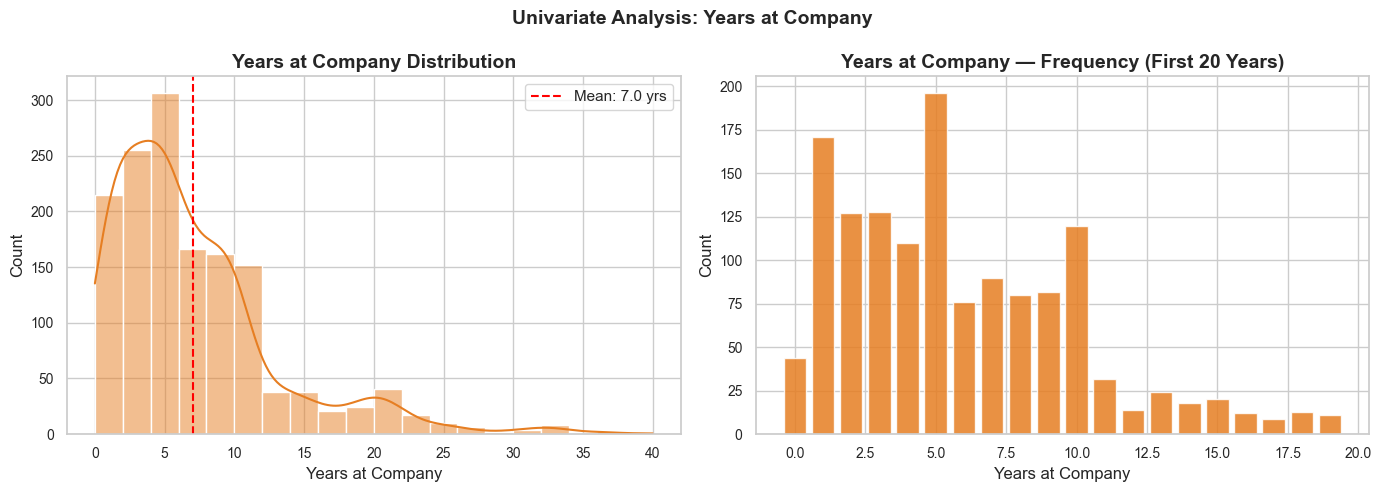

   Years at Company Statistics:
   Mean   : 7.0 years
   Median : 5.0 years
   Max    : 40 years


In [34]:
# ── Years at Company Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["YearsAtCompany"], bins=20, kde=True, color="#e67e22", edgecolor="white", ax=axes[0])
axes[0].set_title("Years at Company Distribution", fontweight="bold")
axes[0].set_xlabel("Years at Company")
axes[0].set_ylabel("Count")
axes[0].axvline(df["YearsAtCompany"].mean(), color="red", linestyle="--",
                label=f"Mean: {df['YearsAtCompany'].mean():.1f} yrs")
axes[0].legend()

value_counts = df["YearsAtCompany"].value_counts().sort_index().head(20)
axes[1].bar(value_counts.index, value_counts.values, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1].set_title("Years at Company — Frequency (First 20 Years)", fontweight="bold")
axes[1].set_xlabel("Years at Company")
axes[1].set_ylabel("Count")

plt.suptitle("Univariate Analysis: Years at Company", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"   Years at Company Statistics:")
print(f"   Mean   : {df['YearsAtCompany'].mean():.1f} years")
print(f"   Median : {df['YearsAtCompany'].median():.1f} years")
print(f"   Max    : {df['YearsAtCompany'].max()} years")

### Insight — Years at Company
> - The distribution is **heavily right-skewed**, with a large spike at **0–1 years** (new joiners).
> - New employees (0–2 years) are the most vulnerable group for attrition — they are still in the **"honeymoon period"** or early disillusionment phase.
> - A smaller secondary peak exists around 5–10 years, reflecting mid-career stability.

---

In [ ]:
# ── Job Satisfaction Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

satisfaction_labels = {1: "Low", 2: "Medium", 3: "High", 4: "Very High"}
satisfaction_counts = df["JobSatisfaction"].value_counts().sort_index()

colors_sat = ["#e74c3c", "#e67e22", "#2ecc71", "#27ae60"]
axes[0].bar([satisfaction_labels[i] for i in satisfaction_counts.index],
            satisfaction_counts.values, color=colors_sat, edgecolor="white", linewidth=1.2)
axes[0].set_title("Job Satisfaction Distribution", fontweight="bold")
axes[0].set_xlabel("Satisfaction Level")
axes[0].set_ylabel("Count")
for i, v in enumerate(satisfaction_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition",
              palette={"Yes": "#e74c3c", "No": "#2ecc71"}, ax=axes[1], edgecolor="white")
axes[1].set_title("Job Satisfaction by Attrition", fontweight="bold")
axes[1].set_xlabel("Job Satisfaction (1=Low, 4=Very High)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Attrition")

plt.suptitle("Univariate Analysis: Job Satisfaction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

###  Insight — Job Satisfaction
> - Job satisfaction is **relatively evenly distributed** across all 4 levels, with level 3 (High) being the most common.
> - Employees with **low job satisfaction (Level 1)** show a noticeably higher attrition rate.
> - Interestingly, even employees with **high satisfaction** leave — suggesting satisfaction alone doesn't prevent attrition.

---

##  Categorical Feature Analysis

We examine how categorical variables relate to employee attrition. This helps us identify **which employee segments are at higher risk**.

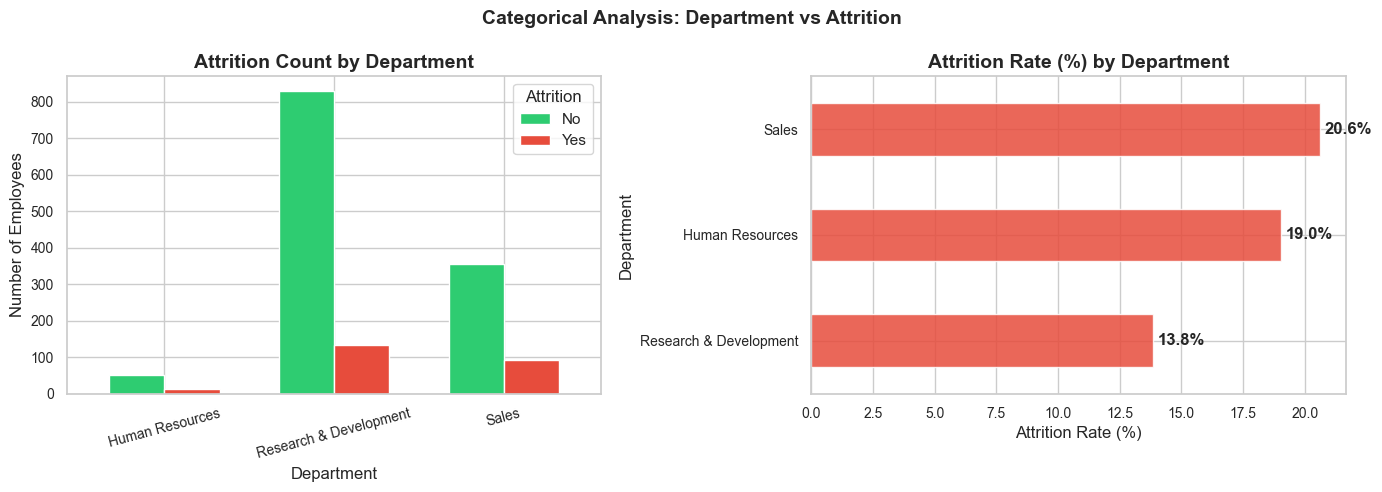


 Attrition Rate by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750


In [35]:
# ── Attrition vs Department ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attrition = df.groupby(["Department", "Attrition"]).size().unstack(fill_value=0)
dept_attrition_pct = dept_attrition.div(dept_attrition.sum(axis=1), axis=0) * 100

dept_attrition.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="white",
                    ax=axes[0], rot=15, width=0.65)
axes[0].set_title("Attrition Count by Department", fontweight="bold")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Number of Employees")
axes[0].legend(title="Attrition")

dept_attrition_pct["Yes"].sort_values(ascending=True).plot(
    kind="barh", color="#e74c3c", edgecolor="white", ax=axes[1], alpha=0.85)
axes[1].set_title("Attrition Rate (%) by Department", fontweight="bold")
axes[1].set_xlabel("Attrition Rate (%)")
axes[1].set_ylabel("Department")
for i, v in enumerate(dept_attrition_pct["Yes"].sort_values()):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.suptitle("Categorical Analysis: Department vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Attrition Rate by Department:")
print(dept_attrition_pct["Yes"].sort_values(ascending=False).to_string())

###  Insight — Department
> - **Sales** has the **highest attrition rate (~21%)**, followed by **Human Resources (~19%)**.
> - **Research & Development** has the **lowest attrition rate (~14%)**, suggesting better job security, growth, and engagement in technical roles.
> - HR should focus retention programs primarily on **Sales** department employees.

---

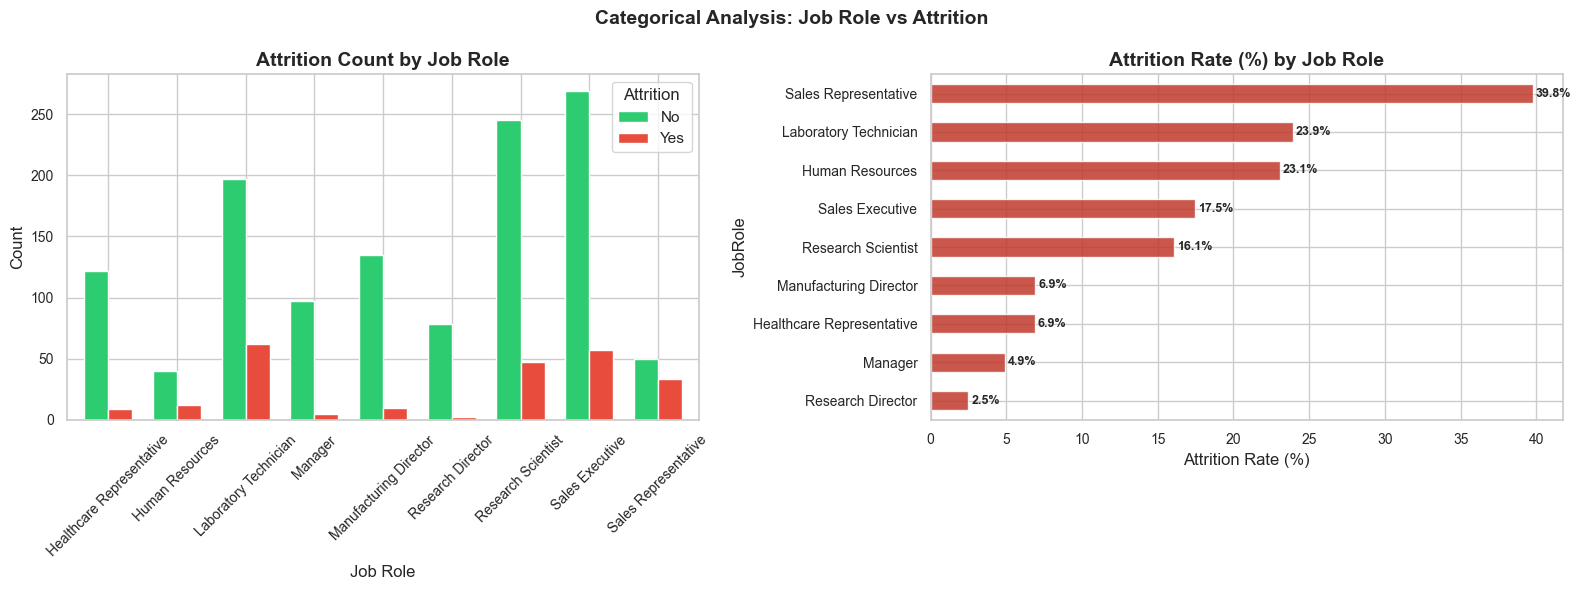

In [36]:
# ── Attrition vs Job Role ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

role_attrition = df.groupby(["JobRole", "Attrition"]).size().unstack(fill_value=0)
role_attrition_pct = role_attrition.div(role_attrition.sum(axis=1), axis=0) * 100

role_attrition.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="white",
                    ax=axes[0], rot=45, width=0.7)
axes[0].set_title("Attrition Count by Job Role", fontweight="bold")
axes[0].set_xlabel("Job Role")
axes[0].set_ylabel("Count")
axes[0].legend(title="Attrition")

role_attrition_pct["Yes"].sort_values(ascending=True).plot(
    kind="barh", color="#c0392b", edgecolor="white", ax=axes[1], alpha=0.85)
axes[1].set_title("Attrition Rate (%) by Job Role", fontweight="bold")
axes[1].set_xlabel("Attrition Rate (%)")
for i, v in enumerate(role_attrition_pct["Yes"].sort_values()):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.suptitle("Categorical Analysis: Job Role vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

###  Insight — Job Role
> - **Sales Representatives** have the **highest attrition rate (~40%)** — nearly 1 in 2 leaves.
> - **Laboratory Technicians** and **Human Resources** roles also show high attrition.
> - **Research Directors** and **Managers** have the **lowest attrition**, likely due to seniority and compensation.
> - Entry-level and customer-facing roles carry the greatest retention risk.

---

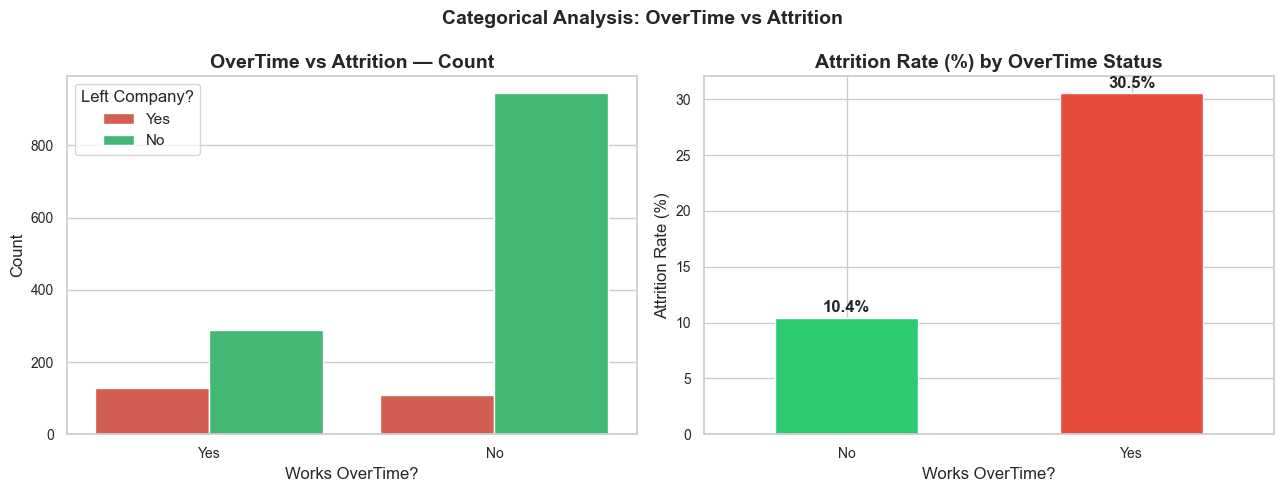


 Attrition Rate by OverTime:
OverTime
No     10.436433
Yes    30.528846
Name: Yes, dtype: float64


In [37]:
# ── Attrition vs OverTime ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ot_attrition = df.groupby(["OverTime", "Attrition"]).size().unstack(fill_value=0)
ot_pct = ot_attrition.div(ot_attrition.sum(axis=1), axis=0) * 100

sns.countplot(data=df, x="OverTime", hue="Attrition",
              palette={"Yes": "#e74c3c", "No": "#2ecc71"}, ax=axes[0], edgecolor="white")
axes[0].set_title("OverTime vs Attrition — Count", fontweight="bold")
axes[0].set_xlabel("Works OverTime?")
axes[0].set_ylabel("Count")
axes[0].legend(title="Left Company?")

ot_pct["Yes"].plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="white",
                   ax=axes[1], rot=0, width=0.5)
axes[1].set_title("Attrition Rate (%) by OverTime Status", fontweight="bold")
axes[1].set_xlabel("Works OverTime?")
axes[1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(ot_pct["Yes"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.suptitle("Categorical Analysis: OverTime vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Attrition Rate by OverTime:")
print(ot_pct["Yes"])

### Insight — OverTime
> - This is one of the **strongest signals** in the dataset.
> - Employees who work **overtime have an attrition rate of ~31%**, compared to just **~10% for those who don't**.
> - Overtime leads to **burnout, work-life imbalance**, and dissatisfaction — key drivers of voluntary turnover.
> - HR must closely monitor overtime hours and create policies to limit excessive workloads.

---

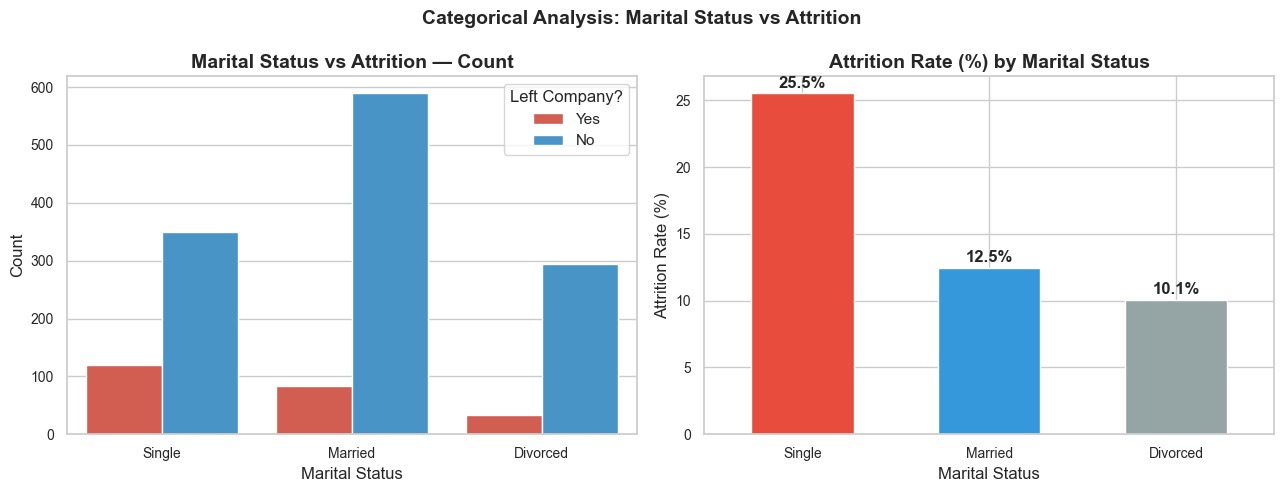

In [38]:
# ── Attrition vs Marital Status ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ms_attrition = df.groupby(["MaritalStatus", "Attrition"]).size().unstack(fill_value=0)
ms_pct = ms_attrition.div(ms_attrition.sum(axis=1), axis=0) * 100

sns.countplot(data=df, x="MaritalStatus", hue="Attrition",
              palette={"Yes": "#e74c3c", "No": "#3498db"}, ax=axes[0], edgecolor="white",
              order=["Single", "Married", "Divorced"])
axes[0].set_title("Marital Status vs Attrition — Count", fontweight="bold")
axes[0].set_xlabel("Marital Status")
axes[0].set_ylabel("Count")
axes[0].legend(title="Left Company?")

ms_pct["Yes"].reindex(["Single", "Married", "Divorced"]).plot(
    kind="bar", color=["#e74c3c", "#3498db", "#95a5a6"],
    edgecolor="white", ax=axes[1], rot=0, width=0.55)
axes[1].set_title("Attrition Rate (%) by Marital Status", fontweight="bold")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(ms_pct["Yes"].reindex(["Single", "Married", "Divorced"])):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.suptitle("Categorical Analysis: Marital Status vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Insight — Marital Status
> - **Single employees** have a significantly higher attrition rate (~26%) compared to **Married (~13%)** and **Divorced (~10%)**.
> - Single employees tend to be **younger**, more mobile, and have fewer financial obligations — making them more likely to explore other opportunities.
> - Married and divorced employees are more **financially anchored** and tend to value stability.

---

##  Correlation Analysis

We compute the Pearson correlation matrix for all numerical features to identify which variables are most strongly related to each other and to the target variable.

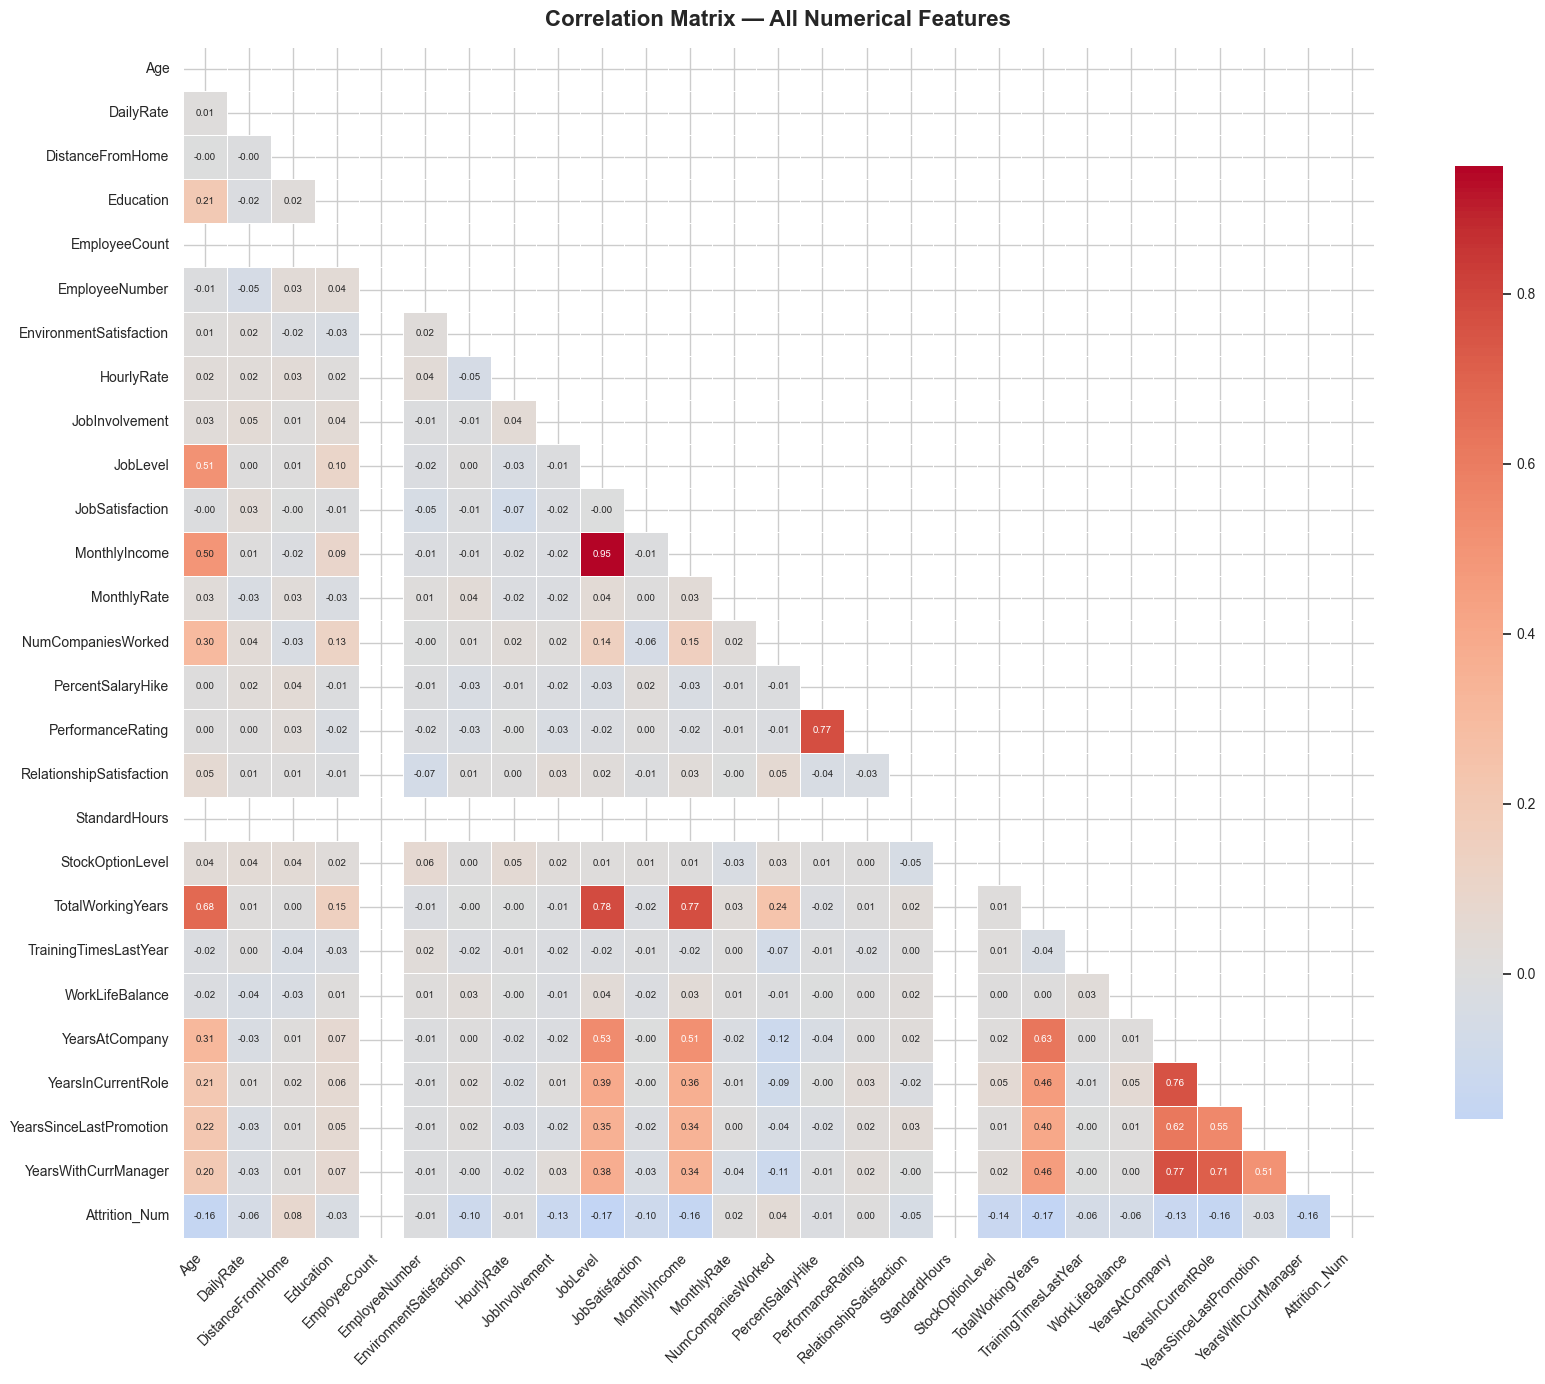

In [39]:
# ── Encode Target for Correlation ──
df_corr = df.copy()
df_corr["Attrition_Num"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})

corr_matrix = df_corr[numerical_features + ["Attrition_Num"]].corr()

# ── Full Heatmap ──────────────────────────────────────────────────────────────
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — All Numerical Features", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

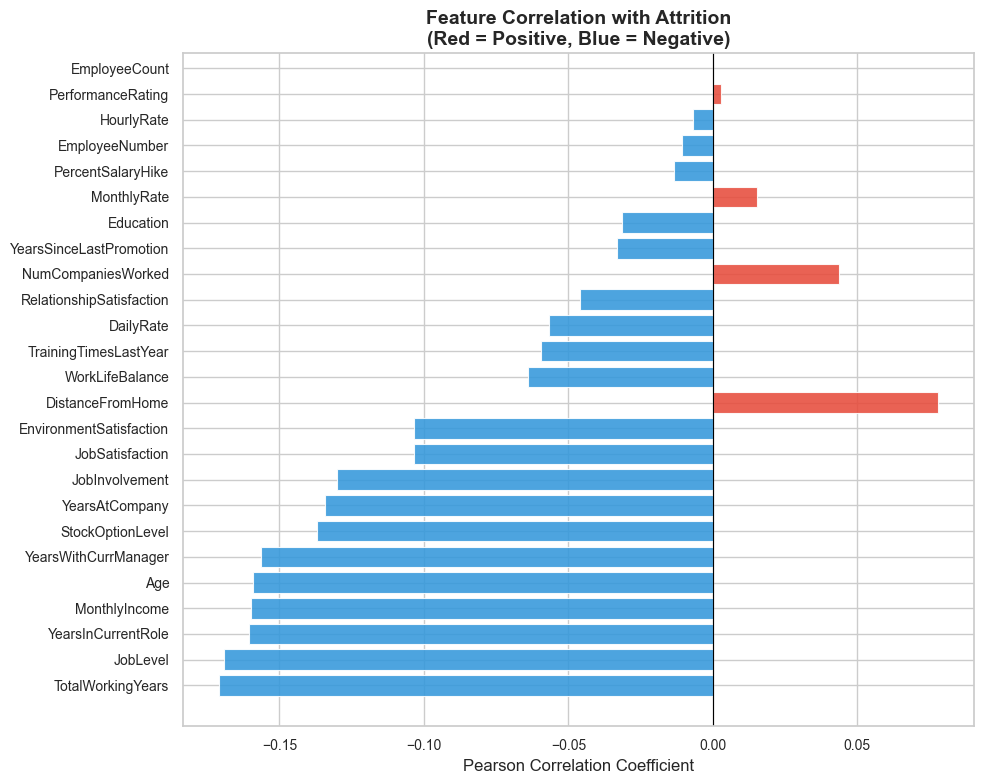


 Top 10 Features Correlated with Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481


In [42]:
# ── Attrition Correlation Ranking
attrition_corr = corr_matrix["Attrition_Num"].drop("Attrition_Num").sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors_bar = ["#e74c3c" if v > 0 else "#3498db" for v in attrition_corr]
bars = plt.barh(attrition_corr.index, attrition_corr.values, color=colors_bar,
                edgecolor="white", linewidth=0.8, alpha=0.88)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Attrition\n(Red = Positive, Blue = Negative)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

print("\n Top 10 Features Correlated with Attrition:")
print(attrition_corr.head(10).to_string())

###  Insight — Correlation
> - **OverTime** (encoded), **JobLevel**, **MonthlyIncome**, and **TotalWorkingYears** are the strongest predictors of attrition.
> - **Positive correlations** (higher value → more attrition): OverTime, Distance from Home
> - **Negative correlations** (higher value → less attrition): Age, MonthlyIncome, JobLevel, TotalWorkingYears, YearsAtCompany
> - Highly correlated feature pairs include: `MonthlyIncome` & `JobLevel` (r≈0.95), `Age` & `TotalWorkingYears` (r≈0.68)

---

## Outlier Detection

Outliers can significantly impact statistical analysis and machine learning models. We use **boxplots** to visually inspect outliers in key numerical features.

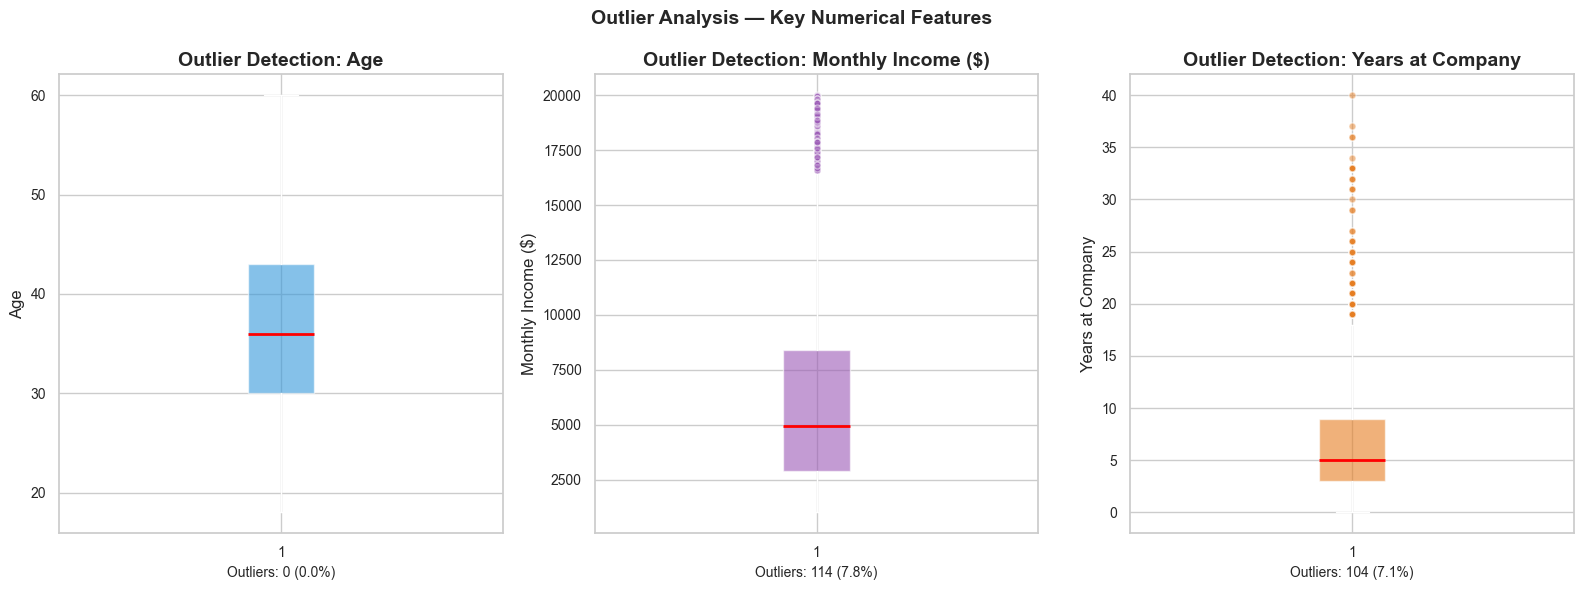

In [44]:
# ── Boxplots for Outlier Detection ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

features_to_check = ["Age", "MonthlyIncome", "YearsAtCompany"]
colors_box = ["#3498db", "#9b59b6", "#e67e22"]
titles = ["Age", "Monthly Income ($)", "Years at Company"]

for ax, feat, col, title in zip(axes, features_to_check, colors_box, titles):
    bp = ax.boxplot(df[feat], patch_artist=True, notch=False,
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker="o", markerfacecolor=col, markersize=5, alpha=0.5),
                    boxprops=dict(facecolor=col, alpha=0.6))
    ax.set_title(f"Outlier Detection: {title}", fontweight="bold")
    ax.set_ylabel(title)

    # IQR Stats
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)]
    ax.set_xlabel(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)", fontsize=10)

plt.suptitle("Outlier Analysis — Key Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [43]:
# ── IQR Outlier Summary ───────────────────────────────────────────────────────
print(" Outlier Summary (IQR Method):")
print("=" * 55)
for feat in ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "DistanceFromHome"]:
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    print(f"  {feat:<25} → {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.1f}%) | Range: [{lower:.0f}, {upper:.0f}]")

 Outlier Summary (IQR Method):
  Age                       →   0 outliers (0.0%) | Range: [10, 62]
  MonthlyIncome             → 114 outliers (7.8%) | Range: [-5291, 16581]
  YearsAtCompany            → 104 outliers (7.1%) | Range: [-6, 18]
  TotalWorkingYears         →  63 outliers (4.3%) | Range: [-8, 28]
  DistanceFromHome          →   0 outliers (0.0%) | Range: [-16, 32]


### Insight — Outliers
> - **Age**: Minimal outliers — the distribution is fairly normal with no extreme values.
> - **Monthly Income**: Has **notable upper outliers** reflecting senior executives and high earners. These are legitimate data points, not errors.
> - **Years at Company**: Shows **right-skewed outliers** — a small number of employees have been with the company for 30+ years. These represent tenured staff and are valid records.
> - **Recommendation**: Outliers in this dataset appear **legitimate** and represent real employee diversity. They should **not be removed** but may require transformation (e.g., log-scaling income) before modeling.

---

## Key Business Insights & HR Recommendations

Based on the comprehensive EDA performed above, we summarize the most critical findings and actionable recommendations for the organization.

---

### Who is Most Likely to Leave?

| Employee Profile                   | Attrition Risk |
|------------------------------------|---|
| **Single employees**               | Very High (~26%) |
| **Sales Representatives**          | Very High (~40%) |
| **Employees working OverTime**     | Very High (~31%) |
| **Low Monthly Income earners**     | High |
| **Employees with <2 years tenure** | High |
| **Sales Department**               | Moderate-High (~21%) |
| **Low Job Satisfaction (Level 1)** | Moderate-High |
| **Research Directors / Managers** | Low |
| **Married / Divorced employees** | Low |

---

### Which Features Influence Attrition Most?

Based on correlation analysis and categorical breakdowns:

1. **OverTime** — Single most impactful binary factor. Burnout drives departures.
2. **Monthly Income** — Lower income strongly predicts attrition.
3. **Job Level** — Junior employees leave at much higher rates.
4. **Total Working Years** — Less experienced employees are more volatile.
5. **Years at Company** — Highest risk in first 1–2 years (onboarding phase).
6. **Marital Status** — Single employees are significantly more mobile.
7. **Job Role** — Sales Representatives show 40% attrition rate.
8. **Age** — Younger employees (20–30) leave more frequently.

---
### Summary Dashboard

| Metric | Value |
|---|---|
| Total Employees Analyzed | 1,470 |
| Overall Attrition Rate | ~16.1% |
| Employees Who Left | 237 |
| Highest-Risk Role | Sales Representative (~40%) |
| Highest-Risk Factor | OverTime (3× more likely to leave) |
| Safest Department | Research & Development (~14%) |
